1. Construya un filtro pasa-bajos ideal (c´ırculo de altura 1 sobre una matriz de
ceros). Cargue una imagen y f´ıltrela en el dominio de frecuencias, y recupere
la imagen suavizada. Visualice las im´agenes y comp´arelas.
Repita el ejercicio para diferentes frecuencias de corte y compruebe la aparici´on
del fen´omeno de Gibbs.
2. Construya un filtro pasa-bajos tipo Butterworth utilizando la definici´on en
frecuencia. Filtre una imagen, modificando la frecuencia de corte y comprobando el efecto sobre la imagen filtrada. Verifique el efecto del filtro respecto
al fen´omeno de Gibbs.
3. Define la funci´on de transferencia h(x, y) de un filtro gaussiano pasa-bajos de
35×35, luego obtenga la respuesta en frecuencia aplicando la TDF. Luego, escale ´esta al tama˜no de la imagen que va a filtrar. (Use dst = cv.resize())
Calcule y visualice la TDF de la imagen y el producto de transformadas,
verificando la acci´on del filtro. Obtenga la imagen filtrada y compare con la
imagen original.
4. Repita el ejercicio anterior pero ahora utilice un filtro gaussiano definido en
frecuencia. Compare los resultados.
5. Repita los ejercicios del 1 al 4, para filtros pasa-altos.

In [109]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider


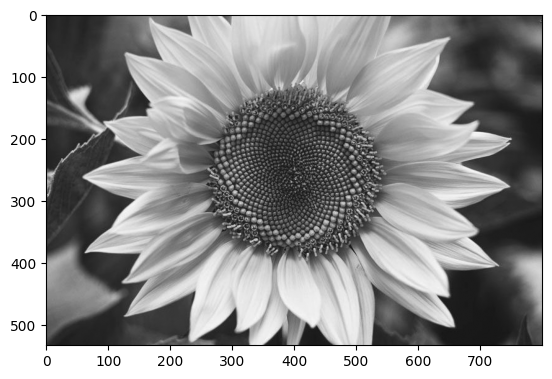

In [110]:
img = cv2.imread("../Imagenes_cursado/flores02.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap = 'gray')
plt.show()

# pasabajo

Filtro pasa bajos

##  Parte 1: ideal
con el filtro pasa altos lo que se busca es atenuar las altas frecuencias, obteniendo una imagen mas suavizada.

Para este ejercicio se nos pide utilizar la mascar asingular para que deje pasar cierto umbral de frecuencia a su transformada de fourier.

Voy a definir un parmatero de radio r que me define cuales frecuencias que me dejará vivas aquellas frecuencias dentro de ese rango y anulará todas aquellas que queden afuera


In [111]:
from matplotlib.widgets import Slider

def aplicar_filtro_ideal(img, r):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2 #centro?)

    f = np.fft.fft2(img) #calculamos la transformada
    f_shift =np.fft.fftshift(f) #desplazamos asi centramos las frecuencias

    #creamos mascara, podriamos hacer un for mejor

    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    mask = dist_from_center <= r

    #forma compacta pythoneana pero para que sea mas rapida que un doble for

    f_filtrada = f_shift * mask #filtramos por producto
    f_ishift = np.fft.ifftshift(f_filtrada) #volvemos las frecuencias normales

    img_back = np.abs(np.fft.ifft2(f_ishift)) #la inversa devuelve complejo

    return img_back, mask

    


In [112]:

from ipywidgets import interact, IntSlider

def visualizacion_interactiva(r):
    img_filt, mask = aplicar_filtro_ideal(img, r)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_filt, cmap='gray')
    plt.title(f"Radio: {r}")
    
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.show()

interact(visualizacion_interactiva, r=IntSlider(min=1, max=200, step=1, value=50))

interactive(children=(IntSlider(value=50, description='r', max=200, min=1), Output()), _dom_classes=('widget-i…

<function __main__.visualizacion_interactiva(r)>

Se puede apreciar el fenomeno de gibss (ejemplo r=32 o menores) donde se prpagan las altas frecuencias o los bordes hacia afuera de la imagen. Esto ocurre porque se filtra a la función original de manera muy abrupta (escalon unitario) lo que implica convolucionar la imagen original con una sinc en el dominio frecuencial

## Parte 2: butterworth

El *filtro butterworth* permite suavizar las frecuencias que pasan y las que se eliminan para mitigar el fenómeno de gibbs.La transición es una curva suave.


La formula es: $$H(u,v) = \frac{1}{1+ \left[D(u,v)/D_0\right]^{2n}}$$ donde:
- $D(u,v)$ es la distancia al centro de la imagen
- D_0 es la frecuencia de corte
- n es un parametro que controla la caida del filtro. Cuando n es grande tiendo al filtro ideal



In [113]:
def aplicar_filtro_butterworth(img, r,n):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2 #centro?)

    f = np.fft.fft2(img) #calculamos la transformada
    f_shift =np.fft.fftshift(f) #desplazamos asi centramos las frecuencias

    #creamos mascara, podriamos hacer un for mejor

    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    
    mask = 1/(1+ (dist_from_center/r)**(2*n))


    #forma compacta pythoneana pero para que sea mas rapida que un doble for

    f_filtrada = f_shift * mask #filtramos por producto
    f_ishift = np.fft.ifftshift(f_filtrada) #volvemos las frecuencias normales

    img_back = np.abs(np.fft.ifft2(f_ishift)) #la inversa devuelve complejo

    return img_back, mask


In [114]:
def mostrar_butterworth(r, n):
    # Usamos tu función ya definida
    img_filt, mask = aplicar_filtro_butterworth(img, r, n)
    
    plt.figure(figsize=(14, 7))
    
    # Visualización de la imagen filtrada
    plt.subplot(1, 2, 1)
    plt.imshow(img_filt, cmap='gray')
    plt.title(f'Butterworth - Radio: {r}, Orden: {n}')
    plt.axis('off')
    
    # Visualización de la máscara (para ver la transición suave)
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Máscara H(u,v)')
    plt.axis('off')
    
    plt.show()

# Creamos la interacción
interact(mostrar_butterworth, 
         r=IntSlider(min=1, max=300, step=1, value=50, description='Radio (r):'),
         n=IntSlider(min=1, max=15, step=1, value=2, description='Orden (n):'))

interactive(children=(IntSlider(value=50, description='Radio (r):', max=300, min=1), IntSlider(value=2, descri…

<function __main__.mostrar_butterworth(r, n)>

## parte 3: filtro gaussiano

Tenemos el filtro pasa bajos gaussiano que se lo define como $$H(u,v)= exp \left\{-D^2(u,v)/2\sigma^2\right\}$$ 
donde en lugar de elegir el radio, elegimos la varianza de la distribucion


In [115]:
def aplicar_filtro_gaussiano(img, sigma):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2 #centro?)

    f = np.fft.fft2(img) #calculamos la transformada
    f_shift =np.fft.fftshift(f) #desplazamos asi centramos las frecuencias

    #creamos mascara, podriamos hacer un for mejor

    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    
    mask = np.exp(-dist_from_center**2 / (2*sigma**2))


    #forma compacta pythoneana pero para que sea mas rapida que un doble for

    f_filtrada = f_shift * mask #filtramos por producto
    f_ishift = np.fft.ifftshift(f_filtrada) #volvemos las frecuencias normales

    img_back = np.abs(np.fft.ifft2(f_ishift)) #la inversa devuelve complejo

    return img_back, mask


In [116]:
def mostrar_gaussiano(sigma):
    # Usamos tu función ya definida
    img_filt, mask = aplicar_filtro_gaussiano(img, sigma)
    
    plt.figure(figsize=(14, 7))
    
    # Visualización de la imagen filtrada
    plt.subplot(1, 2, 1)
    plt.imshow(img_filt, cmap='gray')
    plt.title(f'gaussiano {sigma}')
    plt.axis('off')
    
    # Visualización de la máscara (para ver la transición suave)
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Máscara H(u,v)')
    plt.axis('off')
    
    plt.show()

# Creamos la interacción
interact(mostrar_gaussiano, 
         sigma=IntSlider(min=1, max=100, step=1, value=50, description='Radio (r):'))

interactive(children=(IntSlider(value=50, description='Radio (r):', min=1), Output()), _dom_classes=('widget-i…

<function __main__.mostrar_gaussiano(sigma)>

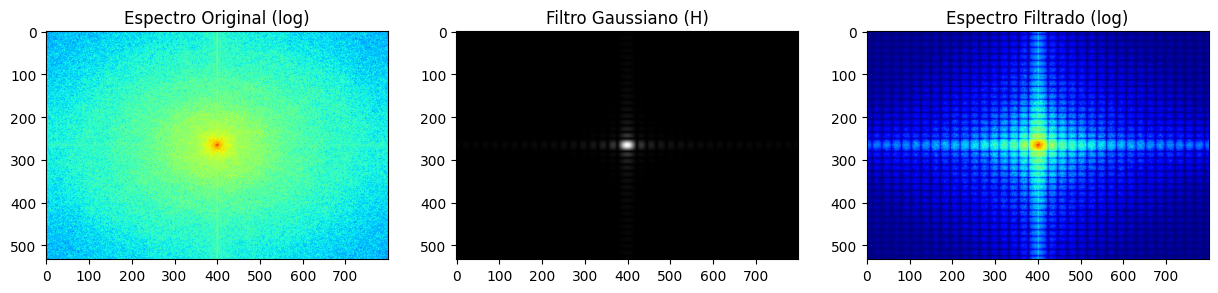

In [117]:
# ahora lo que pide el ejercicio

gaussian_1d = cv2.getGaussianKernel(ksize = 35, sigma = 100)
gaussian_kernel = gaussian_1d @ gaussian_1d.T



#la pasamos a frecuecia
gaussian_fft = np.fft.fftshift(np.fft.fft2(gaussian_kernel, s = img.shape))
#necesitamos centrarlo para que el resize mantenga el centro


#para poder hacer el producto en frecuencia tenemos que agrandar la matriz, interpolando valores intermedios
gaussian_full = cv2.resize(np.abs(gaussian_fft), (img.shape[1], img.shape[0]))


#ahora comparemos el espctro de la imagen original y la transformada

F_shift = np.fft.fftshift(np.fft.fft2(img))
G_shift = F_shift * gaussian_full #el kernel ya esta desplazado!


mag_original = np.log(1 + np.abs(F_shift))
mag_filtrada = np.log(1 + np.abs(G_shift))


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Espectro Original (log)")
plt.imshow(mag_original, cmap='jet')

plt.subplot(1, 3, 2)
plt.title("Filtro Gaussiano (H)")
plt.imshow(gaussian_full, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Espectro Filtrado (log)")
plt.imshow(mag_filtrada, cmap='jet')

plt.show()





Si comparo la convolucion en el dominio espacial con la transformada inversa de la filtrada esperaria lo mismo.

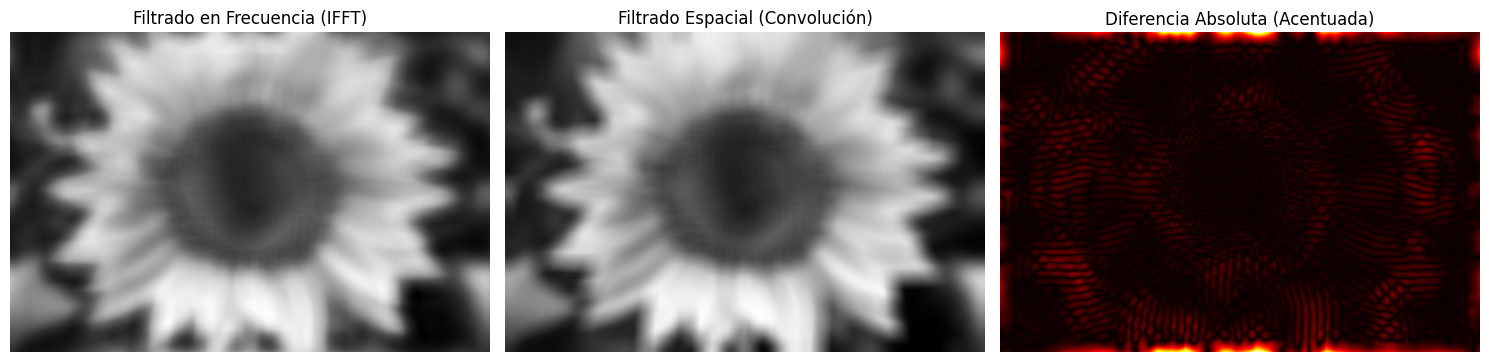

Error Cuadrático Medio (MSE) entre ambos métodos: 26.027097


In [118]:
g_ishift = np.fft.ifftshift(G_shift) #hacemos el desplazamiento inverso
img_from_fft = np.abs(np.fft.ifft2(g_ishift))

img_from_spatial = cv2.filter2D(img, -1, gaussian_kernel)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Filtrado en Frecuencia (IFFT)")
plt.imshow(img_from_fft, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Filtrado Espacial (Convolución)")
plt.imshow(img_from_spatial, cmap='gray')
plt.axis('off')

# 4. Diferencia absoluta para ver dónde difieren (multiplicada para que sea visible)
diff = np.abs(img_from_fft - img_from_spatial)
plt.subplot(1, 3, 3)
plt.title("Diferencia Absoluta (Acentuada)")
plt.imshow(diff * 10, cmap='hot') 
plt.axis('off')

plt.tight_layout()
plt.show()

# Verificación numérica simple
mse = np.mean((img_from_fft - img_from_spatial)**2)
print(f"Error Cuadrático Medio (MSE) entre ambos métodos: {mse:.6f}")



# Pasaaltos
Los filtros pasalots son las versiones inversas de los filtros anteriores. Las salidas van a ser solo bordes.

Se pierde el brillo medio porque pasan las frecuencias mayores que 0,0

## Parte 1: Pasaalto ideal
Se ve gris porque se mueve el 0 hacia los valores negativos

In [119]:
def aplicar_filtro_pasa_alto(img, r):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # Transformada y centrado
    f = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f)

    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    mask = dist_from_center > r  

    # Filtrado
    f_filtrada = f_shift * mask
    
    # Inversa
    f_ishift = np.fft.ifftshift(f_filtrada)
    img_back = np.real(np.fft.ifft2(f_ishift))

    return img_back, mask

In [120]:
def visualizacion_pasa_alto(r):
    # Asumiendo que 'img' ya está cargada en el entorno
    img_filt, mask = aplicar_filtro_pasa_alto(img, r)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_filt, cmap='gray')
    plt.title(f"Pasa-Altos (Radio: {r})")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Máscara (Frecuencias)")
    plt.axis('off')
    plt.show()

# Widget interactivo
interact(visualizacion_pasa_alto, r=IntSlider(min=0, max=150, step=1, value=20))

interactive(children=(IntSlider(value=20, description='r', max=150), Output()), _dom_classes=('widget-interact…

<function __main__.visualizacion_pasa_alto(r)>

Se observa el mismo efecto de gibbs al usar umbrales pequeños

## pasaltos rutterworth

## pasa alto gaussiano

## filtrado de alta potencia

Vimos que la mascara difusa para A > 1 se escribia como $$f_{AP}(x,y) = A f(x,y) - f_{PB}(x,y)$$ quedandonos con principalmente las frecuencias altas de las imagenes ya que las bajas se anulan y a su vez resalta o incrementa las frecuencias altas.

Vimos que se podría escribircomo $$f_{AP}= (A-1)f(x,y) + f_{PA}(x,y)$$ y como la transfromada es lineal podemos aplicar fourier a ambos lados y obtener $$G_{AP}(u,v)=(A-1)F(u,v) + G_{PA}(u,v)$$

## filtrado de enfasis

Se lo define como $$H_{EAF}(u,v)= a + b H_{PA} (u,v)$$ donde con la transformada del pasaaltos amplificamos su efecto y ademas sumarle una continuapara el brillo original (frecuencia 0,0)



In [ ]:
def filtrado_enfasis(img, r, a,b, n):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    f = np.fft.fft2(img) #le saco la transformada de fourier a la img
    f_shift = np.fft.fftshift(f) #la centro

    #creamos alguna mascara pasa altos por ejemplo la ideal
    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
    h_pa = 1 / (1 + (r / (dist_from_center + 1e-8))**(2 * n))

    h_enfasis = a + b * h_pa

    f_filtrada = f_shift * h_enfasis
    img_back = np.fft.ifft2(np.fft.ifftshift(f_filtrada))
    img_final = np.real(img_back)

    return img_final, h_enfasis

def visualizacion_enfasis(r, a, b, n):
    # Asegurate de que la variable 'img' esté cargada en tu celda antes de esto
    res, mascara = filtrado_enfasis(img, r, a, b, n)
    
    plt.figure(figsize=(18, 6))
    plt.suptitle(f"Énfasis Butterworth: $H(u,v) = a + b \cdot H_a(u,v)$", fontsize=16)
    
    # 1. Imagen Original
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Imagen Original")
    plt.axis('off')
    
    # 2. Imagen con Énfasis (Butterworth)
    plt.subplot(1, 3, 2)
    plt.imshow(res, cmap='gray', vmin=np.min(img), vmax=np.max(img))
    plt.title(f"Resultado (n={n})")
    plt.axis('off')
    
    # 3. La Máscara
    plt.subplot(1, 3, 3)
    im_mask = plt.imshow(mascara, cmap='viridis')
    plt.title(f"Filtro H(u,v) - Radio: {r}")
    plt.colorbar(im_mask, fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Llamada interactiva corregida
interact(visualizacion_enfasis, 
         r=IntSlider(min=1, max=100, step=1, value=20, description='Radio (D0)'),
         a=FloatSlider(min=0.0, max=2.0, step=0.1, value=0.5, description='a (Offset)'),
         b=FloatSlider(min=0.0, max=5.0, step=0.1, value=1.5, description='b (Ganancia)'),
         n=IntSlider(min=1, max=5, step=1, value=2, description='Orden n'))

<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:26: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nadador frustrado\AppData\Local\Temp\ipykernel_11604\4087097963.py:26: SyntaxWarning: invalid escape sequence '\c'
  plt.suptitle(f"Énfasis Butterworth: $H(u,v) = a + b \cdot H_a(u,v)$", fontsize=16)


interactive(children=(IntSlider(value=20, description='Radio (D0)', min=1), FloatSlider(value=0.5, description…

<function __main__.visualizacion_enfasis(r, a, b, n)>